Importowanie bibliotek

In [44]:
from sklearn.datasets import load_iris, load_breast_cancer, fetch_openml
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time
import joblib
import json

### Zadanie 2
Analiza zbioru danych Iris:
- Wczytaj zbiór danych Iris z biblioteki scikit-learn.
- Przeprowadź podstawową eksplorację danych, taką jak wyświetlenie kilku pierwszych wierszy danych, informacje o kolumnach itp.
- Przygotuj dane do budowy modeli klasyfikacji.
- Zbuduj klasyfikator k-najbliższych sąsiadów (KNN) do klasyfikacji gatunków irysów.
- Oceń jakość klasyfikatora za pomocą różnych metryk, takich jak dokładność, precyzja, czułość i specyficzność.
- Zinterpretuj wyniki i zidentyfikuj najlepszy model.

Wczytywanie zbioru i eksploracja

In [2]:
dataset = load_iris()

In [3]:

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target
df['target_names'] = df['target'].apply(lambda x: dataset.target_names[x])

print(df.sample(5))
print("Dataframe types:\n",df.dtypes)
print("Dataframe shape:", df.shape)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
30                 4.8               3.1                1.6               0.2   
146                6.3               2.5                5.0               1.9   
100                6.3               3.3                6.0               2.5   
29                 4.7               3.2                1.6               0.2   
84                 5.4               3.0                4.5               1.5   

     target target_names  
30        0       setosa  
146       2    virginica  
100       2    virginica  
29        0       setosa  
84        1   versicolor  
Dataframe types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
target_names          object
dtype: object
Dataframe shape: (150, 6)


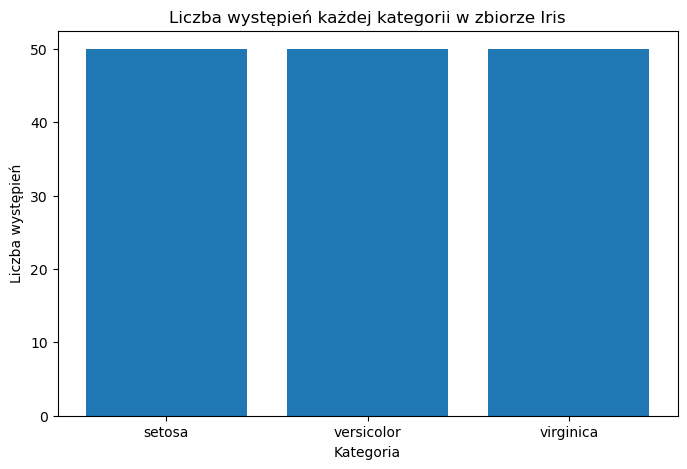

In [4]:
plt.figure(figsize=(8, 5))
category_counts = df['target_names'].value_counts()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Kategoria')
plt.ylabel('Liczba występień')
plt.title('Liczba występień każdej kategorii w zbiorze Iris')
plt.show()

Przygotowywanie danych do modelu:
- wczytany został oczyszczony zbiór, więc pomijam ten etap,
- podział datasetu na X i Y,
- następny będzie podział na dane treningowe/testowe,
- skalowanie danych (po podziale, aby nie było wycieków),
- dopasowanie modelu.

In [5]:
X = df.drop(['target', 'target_names'], axis=1)
y = df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Tworzenie modelu:
- testowane będą rózne parametry K (dopasowanie hiperparametru za pomocą walidacji krzyzowej, pomijam parzyste K, aby uniknąć "remisów")
- oryginalny zbiór danych jest idealnie zrównowazony, stąd skorzystam z metryki 'accuracy'.

In [8]:
k_hyper_param = [i for i in range(1, 16,2)]
cv_scores = []
train_scores = []

In [9]:
for k in k_hyper_param:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))

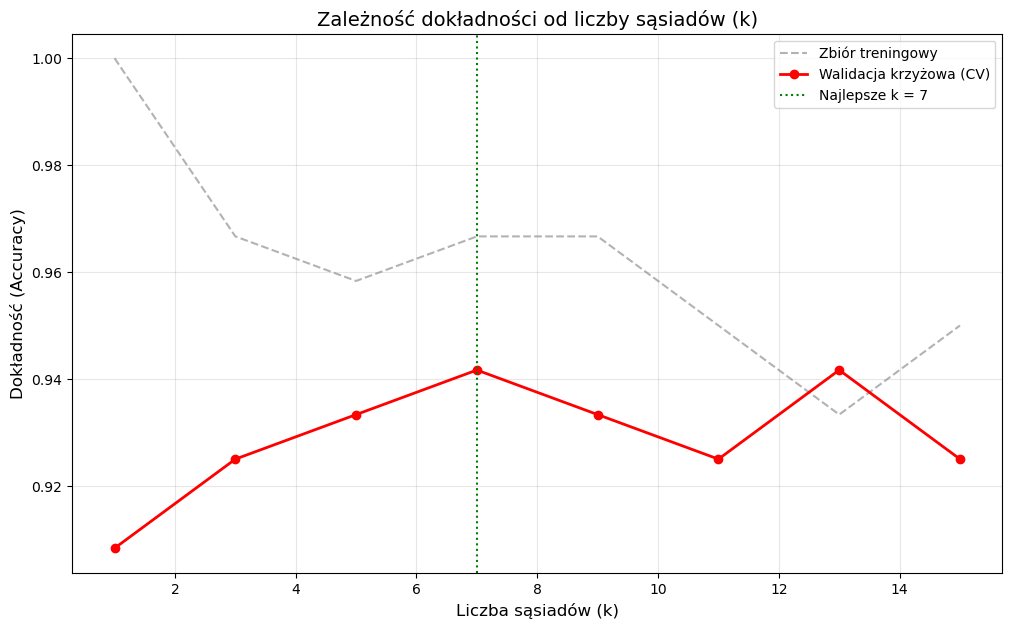

In [10]:
plt.figure(figsize=(12, 7))
plt.plot(k_hyper_param, train_scores, label='Zbiór treningowy', color='gray', linestyle='--', alpha=0.6)
plt.plot(k_hyper_param, cv_scores, label='Walidacja krzyżowa (CV)', color='red', linewidth=2, marker='o')

best_k = k_hyper_param[np.argmax(cv_scores)]
plt.axvline(x=best_k, color='green', linestyle=':', label=f'Najlepsze k = {best_k}')

plt.title('Zależność dokładności od liczby sąsiadów (k)', fontsize=14)
plt.xlabel('Liczba sąsiadów (k)', fontsize=12)
plt.ylabel('Dokładność (Accuracy)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Trenowanie i testowanie na całym zbiorze

Accuracy (test dataset): 1.0


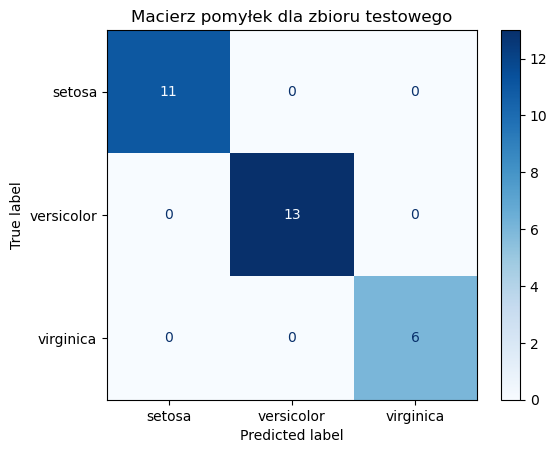

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
test_accuracy = knn.score(X_test_scaled, y_test)
print(f"Accuracy (test dataset): {test_accuracy}")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Macierz pomyłek dla zbioru testowego')
plt.show()


Otrzymaliśmy niepokojąco wysoki wynik ze zbioru testowego, moze to wynikać z tego, ze zbiór został spreparowany i posiada wyrazne róznice między klasami.

### Zadanie 3
- Wczytaj zbiór danych Breast Cancer Wisconsin.
- Przeprowadź czyszczenie i przygotowanie danych, usuwając brakujące wartości, skalując cechy itp.
- Podziel zbiór danych na zestawy treningowy i testowy.
- Zbuduj model regresji logistycznej do klasyfikacji nowotworów jako łagodnych lub złośliwych.
- Oceń jakość klasyfikatora za pomocą różnych metryk oceny, takich jak dokładność, precyzja, czułość i specyficzność.
- Zinterpretuj wyniki i porównaj je z innymi modelami, jeśli to możliwe.


Wczytywanie oraz czyszczenie danych:

In [12]:
dataset = load_breast_cancer()

In [13]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target
df['target_names'] = df['target'].apply(lambda x: dataset.target_names[x])

In [14]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [15]:
print(df.sample(5))
print("Dataframe types:\n",df.dtypes)
print("Dataframe shape:", df.shape)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
239        17.46         39.28          113.40      920.6          0.09812   
172        15.46         11.89          102.50      736.9          0.12570   
354        11.14         14.07           71.24      384.6          0.07274   
82         25.22         24.91          171.50     1878.0          0.10630   
436        12.87         19.54           82.67      509.2          0.09136   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
239           0.12980         0.14170              0.08811         0.1809   
172           0.15550         0.20320              0.10970         0.1966   
354           0.06064         0.04505              0.01471         0.1690   
82            0.26650         0.33390              0.18450         0.1829   
436           0.07883         0.01797              0.02090         0.1861   

     mean fractal dimension  ...  worst perimeter  worst area  \
239

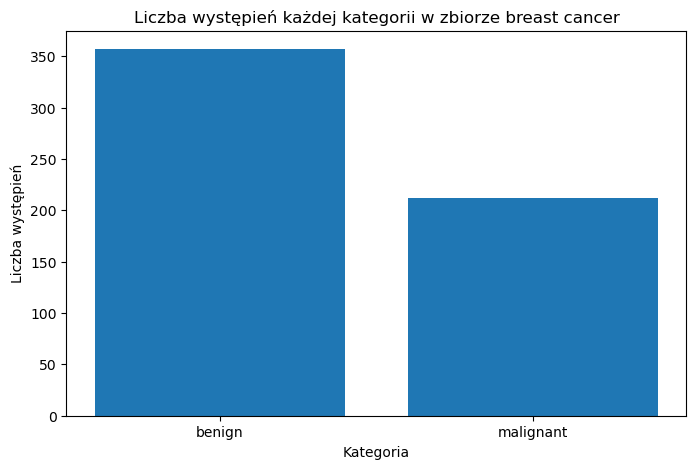

In [16]:
plt.figure(figsize=(8, 5))
category_counts = df['target_names'].value_counts()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Kategoria')
plt.ylabel('Liczba występień')
plt.title('Liczba występień każdej kategorii w zbiorze breast cancer')
plt.show()

Znając kontekst danych oraz widząc rozkład danych, będzie nam zalezeć na minimalizacji liczby przeoczeń (nawet kosztem ogólnej wydajności, metryka recall).

Populacja osób chorych wydaje się być nienaturalnie wysoka w porównaniu do zdrowych.

Podział danych:

In [17]:
X = df.drop(['target', 'target_names'], axis=1)
y = df['target']

In [18]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=0)

Skalowanie:

In [19]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Budowa regresji logistycznej:

In [20]:
grid_hyper_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    "class_weight": [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}],
    'solver': ['liblinear']
}

In [21]:
grid = GridSearchCV(LogisticRegression(), grid_hyper_params, cv=5, scoring='recall')

In [22]:
grid.fit(X_train_scaled, y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best recall score:", grid.best_score_)
cv_c = grid.best_params_['C']
cv_class_weight = grid.best_params_['class_weight']
cv_penalty = grid.best_params_['penalty']

Best hyperparameters: {'C': 0.1, 'class_weight': {0: 1, 1: 2}, 'penalty': 'l2', 'solver': 'liblinear'}
Best recall score: 1.0


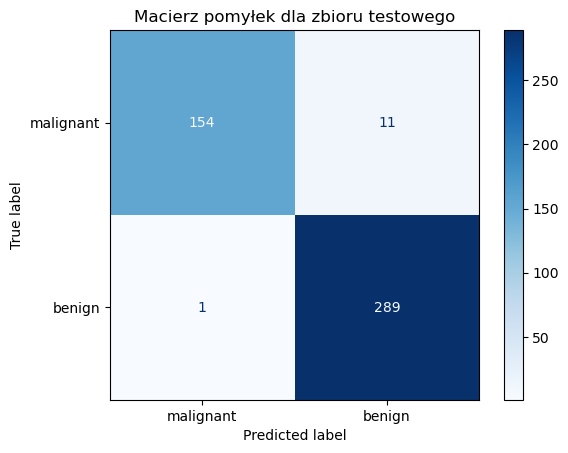

In [23]:
lr = LogisticRegression(C=cv_c, class_weight=cv_class_weight, penalty=cv_penalty, solver='liblinear')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Macierz pomyłek dla zbioru testowego')
plt.show()

Dla defaultowych hiperparametrów, wyniki przedstawiały 2 fałszywe alarmy mniej, za to 1 przeoczenie więcej co jest poprawą na lepsze w kontekście wykrywania chorób.

### Zadanie 4
- Wczytaj zbiór danych Digits (MNIST) zawierający obrazy cyfr.
- Przeprowadź proces przygotowania danych, takich jak spłaszczenie obrazów i standaryzacja wartości pikseli.
- Zastosuj algorytm maszyny wektorów nośnych (SVM) do klasyfikacji cyfr.
- Oceń jakość klasyfikatora za pomocą metryk, takich jak dokładność i macierz pomyłek.
- Zinterpretuj wyniki, analizując, które cyfry są klasyfikowane najczęściej błędnie.

Wczytywanie i analiza zbioru

In [24]:
dataset = fetch_openml(name='mnist_784', version=1, as_frame=True)

In [25]:
df = dataset.frame.copy()

label_col = dataset.target.name if dataset.target.name in df.columns else None
if label_col is None:
    df['target'] = dataset.target.astype(int)
else:
    df[label_col] = df[label_col].astype(int)
    if label_col != 'target':
        df.rename(columns={label_col: 'target'}, inplace=True)

In [26]:
df.sample(5)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
40520,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
66112,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
34216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
5176,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
45414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [27]:
print('Rozmiar DataFrame:', df.shape)
print('Typy danych w DataFrame:\n', df.dtypes)

Rozmiar DataFrame: (70000, 785)
Typy danych w DataFrame:
 pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
pixel5      int64
            ...  
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
target      int64
Length: 785, dtype: object


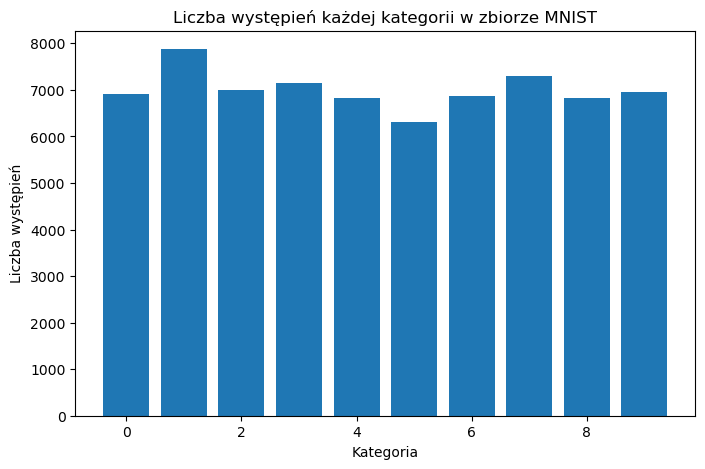

In [37]:
plt.figure(figsize=(8, 5))
category_counts = df['target'].value_counts()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Kategoria')
plt.ylabel('Liczba występień')
plt.title('Liczba występień każdej kategorii w zbiorze MNIST')
plt.show()

Podział i skalowanie zbioru

In [29]:
X = df.drop(['target'], axis=1)
y = df['target']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [31]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Dane zostały pobrane jako juz spłaszczone.

Dobór hiperparametrów i dopasowanie.

In [32]:
svc_hyperparams = {
    'C': [1, 10, 100],
    'gamma': [0.01, 0.001, 'scale'],
    'kernel': ['rbf', 'poly']
}

In [ ]:
# start_time = time.time()
# print(f"Started fitting SVC model with best hyperparameters, start time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")
# grid = GridSearchCV(SVC(), svc_hyperparams, cv=5, scoring='accuracy', verbose=True)
# grid.fit(X_train_scaled, y_train)
# end_time = time.time()
# print(f"Grid Search completed in {end_time - start_time} seconds, end time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")

Starting Grid Search for SVC, start time: 2026-04-28 20:38:49
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Grid Search completed in 44563.10772943497 seconds, end time: 2026-04-29 09:01:33


#### Wyniki grid search
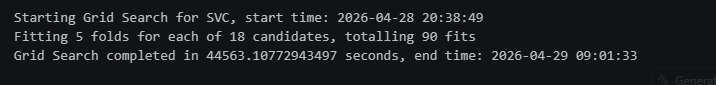

Po ponad 12 godzinach udało się wyternować model, ze względu na czas trenowania, w późniejszym etapie zapiszę jego stan w osobnym pliku.

In [ ]:
# cv_C = grid.best_params_['C']
# cv_gamma = grid.best_params_['gamma']
# cv_kernel = grid.best_params_['kernel']

In [ ]:
# start_time = time.time()
# print(f"Started fitting SVC model with best hyperparameters, start time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")
# svc_model = SVC(C=cv_C, gamma=cv_gamma, kernel=cv_kernel)
# svc_model.fit(X_train_scaled, y_train)
# end_time = time.time()
# print(f"SVC model fitting completed in {end_time - start_time} seconds, end time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")

Started fitting SVC model with best hyperparameters, start time: 2026-04-29 09:01:33
SVC model fitting completed in 272.52280831336975 seconds, end time: 2026-04-29 09:06:05


In [ ]:
# y_pred = svc_model.predict(X_test_scaled)
# test_accuracy = svc_model.score(X_test_scaled, y_test)

In [ ]:
# print(f"Accuracy (test dataset): {test_accuracy}")

Accuracy (test dataset): 0.9772142857142857


Wyniki wg. metryki Accuracy: Accuracy (test dataset): 0.9772142857142857


### Zapis stanu modelu
- zapisuję parametry wytrenowanego modelu oraz scalera,
- zapiszę również wyniki najlepszych parametrów

In [ ]:
# best_hyperparams = grid.best_params_
# best_hyperparams
# with open('best_parameters.json', 'w') as f:
#     json.dump(best_hyperparams, f, indent=4)

In [ ]:
# model_data = {
#     'model': svc_model,
#     'scaler': sc,
#     'params': grid.best_params_,
#     'accuracy': grid.best_score_  
# }

# joblib.dump(model_data, 'svc_complete_package.joblib')

['svc_complete_package.joblib']

### Zadanie 4, przy użyciu PCA oraz Rapids
Ze względu na to, że biblioteka rapids nie działa natywnie na windowsie, będę dokumentował kroki w formie zrzutów ekranu.

#### Konfiguracja Jupytera na WSL
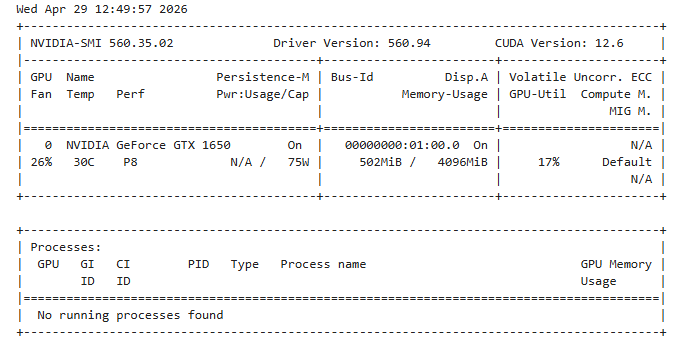

#### Kolejne przeprowadzone kroki
- podział danych na treningowe, testowe,
- skalowanie,
- pca,
- grid_search,
- trenowanie modelu na całych danych

#### Zużycie GPU w trakcie grid search
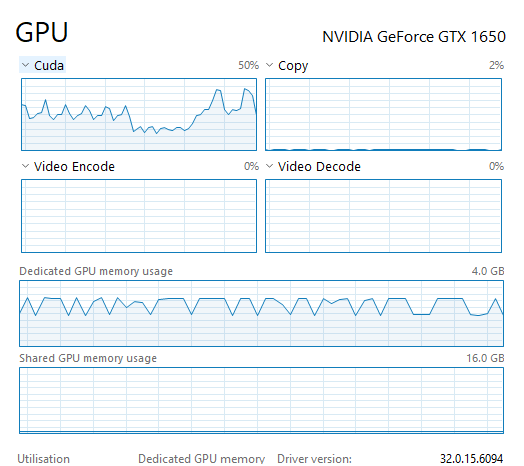

#### Wydajność grid search z PCA oraz Rapids
Started fitting SVC model with best hyperparameters, start time: 2026-04-29 13:03:48 \
Fitting 5 folds for each of 18 candidates, totalling 90 fits \
Grid Search completed in 502.4214496612549 seconds, end time: 2026-04-29 13:12:10

Z ponad 12 godzin czas wyłaniania kandydata spadł do około 10 minut!

#### Wyniki na całych danych
- trenowanie modelu zajęło maksymalnie kilka sekund,
- uzyskano wynik minimalnie gorszy (Accuracy: 0.9759285714285715, w porównaniu do 0.9772142857142857 z datasetu bez PCA), prawdopodobnie można uzyskać lepszy wynik dostosowując liczbę wymiarów,
- zmianę technik uznaję za opłacalną, ze względu na czas działania (szybka możliwość zmiany parametrów w celu poprawy wyniku)

#### Macierz pomyłek
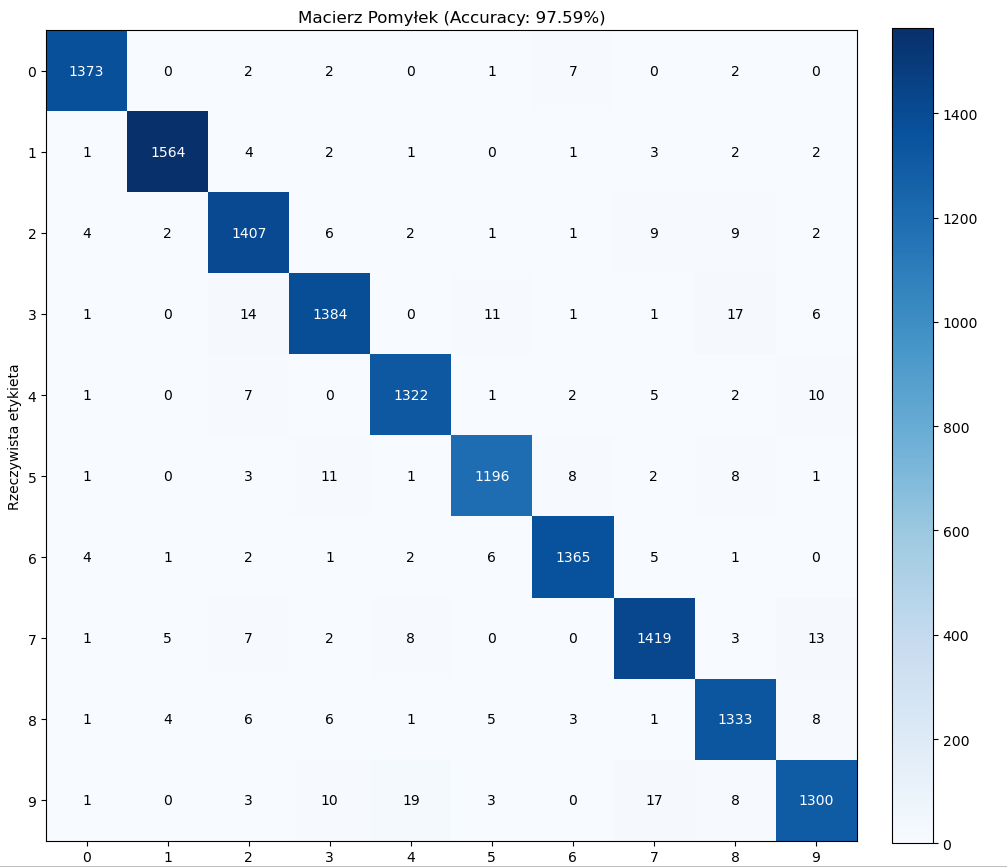 \
Najczęściej mylono "4" z "9" oraz "3" z "8".

### Zadanie 5
- Wczytaj zbiór danych Titanic zawierający informacje o pasażerach statku,
- Przeprowadź analizę eksploracyjną danych, identyfikując istotne cechy dla przewidywania
przeżycia,
- Przygotuj dane do budowy modeli klasyfikacji, usuwając brakujące wartości i kodując
zmienne kategoryczne,
- Zbuduj modele klasyfikacji, takie jak regresja logistyczna lub drzewo decyzyjne, do przewidywania przeżycia pasażerów,
- Oceń jakość klasyfikatorów za pomocą metryk oceny, takich jak dokładność i krzywa ROC-AUC,
-  Zinterpretuj wyniki i zidentyfikuj czynniki mające największy wpływ na przeżycie.